# M4: test-retest reliability of behavioral centroid/shape features

`PLANbeh.md` M4: cross-session ICC for the centroid and M2 shape features, HC and PD only -- CVD is excluded, since most CVD subjects have only 1 session (6/7 deutan, 6/8 protan) and a reliability check needs paired sessions per subject.

`orientation_deg` is periodic (folds to `[0, 180)`, same as `ssvep_beh_fm100/scripts/fm100_features.py`'s `VKS_Angle`), so it's checked with `pingouin.circ_corrcc` instead of a linear ICC -- see `beh/scripts/retest.py`'s docstring.

In [1]:
import sys
sys.path.append('../scripts')

import loader
import retest

# retest's own import of ssveps' reliability.py inserts ssveps/scripts at
# sys.path[0] -- ssveps/scripts has its own plotting.py too, so this must
# also go to sys.path[0] (not just appended), or 'import plotting' below
# would silently resolve to ssveps' version instead.
sys.path.insert(0, '../../ssvep_beh_fm100/scripts')
import plotting as reliability_plotting  # plot_reliability_table -- generic over any {feature, value, p_value} table

df = loader.load_behavioral()

hc_paired = retest.paired_subjects(df, group='CTR')
pd_paired = retest.paired_subjects(df, group='PD')
print(f'HC: {len(hc_paired)} subjects with session 1 and session 2 data')
print(f'PD: {len(pd_paired)} subjects with session 1 and session 2 data')

HC: 21 subjects with session 1 and session 2 data
PD: 6 subjects with session 1 and session 2 data


## HC reliability

In [2]:
hc_reliability = retest.reliability_table(df, group='CTR')
hc_reliability

,feature,n,statistic,value,p_value
0,centroid_red,21,icc,0.254040,0.129475
1,centroid_green,21,icc,0.600755,0.001251
2,along_var,21,icc,0.196294,0.156291
3,perp_var,21,icc,0.165036,0.211334
4,orientation_deg,21,circ_r,0.479799,0.130323


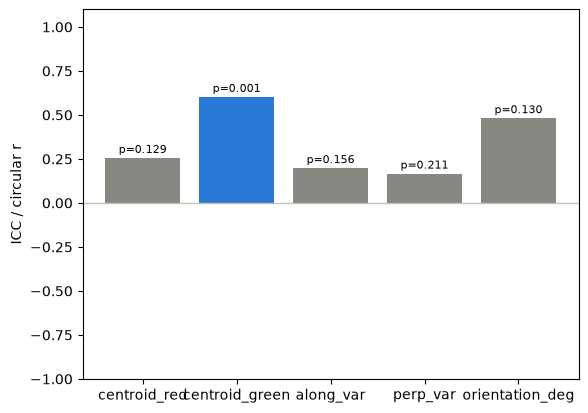

In [3]:
reliability_plotting.plot_reliability_table(hc_reliability);

## PD reliability

In [4]:
pd_reliability = retest.reliability_table(df, group='PD')
pd_reliability

,feature,n,statistic,value,p_value
0,centroid_red,6,icc,0.550181,0.113445
1,centroid_green,6,icc,-0.202305,0.668584
2,along_var,6,icc,0.575921,0.084985
3,perp_var,6,icc,0.123882,0.385125
4,orientation_deg,6,circ_r,0.764812,0.117175


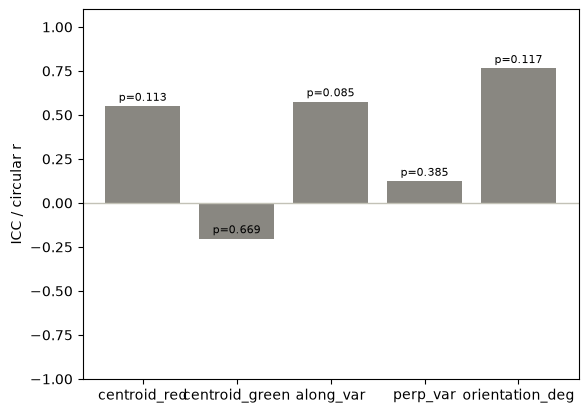

In [5]:
reliability_plotting.plot_reliability_table(pd_reliability);

## Summary

**HC (n=21 paired) is mostly not reliable session-to-session.** Only `centroid_green` clears significance (ICC=0.60, p=0.0013); `centroid_red` (ICC=0.25), `along_var` (ICC=0.20), `perp_var` (ICC=0.17), and `orientation_deg` (circular r=0.48) are all non-significant at this n. **PD (n=6 paired)** shows the same pattern (nothing clears significance, though `along_var`'s ICC=0.58 and `orientation_deg`'s circular r=0.76 are both suggestively high at a sample size too small to confirm it).

Read together with M2's headline finding (`orientation_deg` perfectly separates protan/deutan): that result held on data pooled across *all* of a subject's sessions, which is a fundamentally different (and more forgiving) question than "does session 1 alone predict session 2 alone." This reliability check doesn't contradict M2 -- but it's a real caveat worth carrying forward: don't assume any single session's shape features are individually trustworthy without checking, the same lesson `ssveps/`'s M9 and FM100's M1 reliability work already taught for their own measures. More paired-session HC/PD data would sharpen this; CVD remains untestable here until more subjects have a second session.